In [2]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10_sandbox
import numpy as np
import crocoddyl

config = UR10_sandbox
robot_mj_model = RobotMujocoModel(config.mjcf_path, config.list_of_joints)
robot_pin_model = RobotPinocchioModel(config.urdf_path, config.list_of_joints)
controller = RobotController(robot_pin_model)

DT = robot_mj_model.model.opt.timestep
nq = len(config.list_of_joints)
print(f"Timestep: {DT*1000:.2f} ms  |  DOF: {nq}")


Timestep: 2.00 ms  |  DOF: 6


[0 1 2 3 4 5]
No warm start provided; computing warm start using PD control.


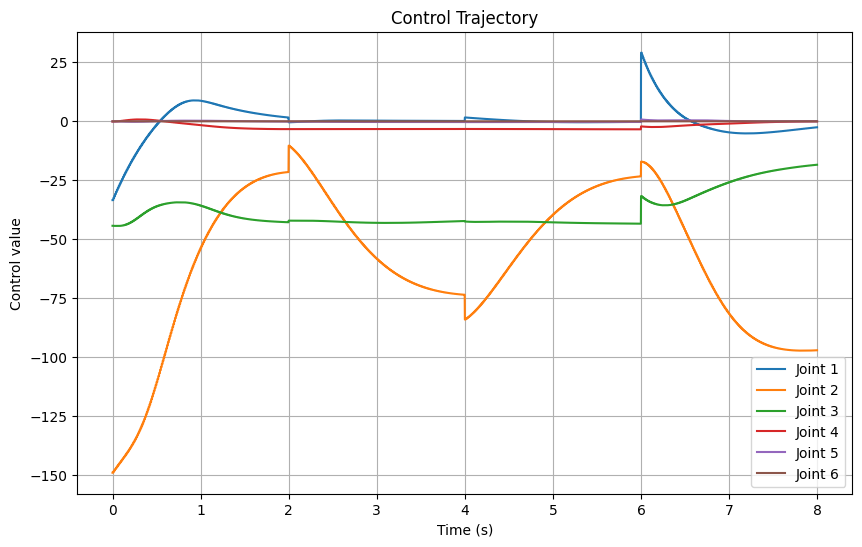

In [3]:
path = [robot_pin_model.current_q(),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([ 0.4, -0.4, 1.5, -0.8,  1.5,  0.5])]

N_steps = 1000   # simulation steps per segment
DT_ocp = 0.01          # 50 ms per OCP step  (not sim_dt = 0.002 s)
T_mpc  = 100            # 20 × 50 ms = 1 s horizon
step   = int(round(DT_ocp / robot_mj_model.model.opt.timestep))  # = 25
# mpc_visualize passes x_start = [q, v] (len 2*nq); slice to q only for compute_control.
# compute_control returns (xs, us); [1] selects us so mpc_visualize can index u[0, :nu].
func = lambda warm_xs, warm_us, x_start, x_target: controller.compute_control(
    x_start, x_target,
    T=T_mpc, DT=DT_ocp,
    option="crocoddyl_advanced", solver=crocoddyl.SolverBoxFDDP,
    # track_weight=1e2, ctrl_weight=1, terminal_weight=1e8,
    kp=config.kp, kd=config.kd,
    warm_xs=warm_xs, warm_us=warm_us)

robot_mj_model.reset()
print(robot_mj_model.u_indices)

xs_mpc, us_mpc = robot_mj_model.mpc_visualize(
    path,
    compute_control=func,
    segment_lengths=[N_steps] * (len(path) - 1),
    dt=DT,
    hold=False,
    step = step,
    # zoh=True
)
robot_mj_model.plot_controls(us_mpc, dt=DT)
# print(f"Collected {len(xs_mpc)} states, {len(us_mpc)} controls.")


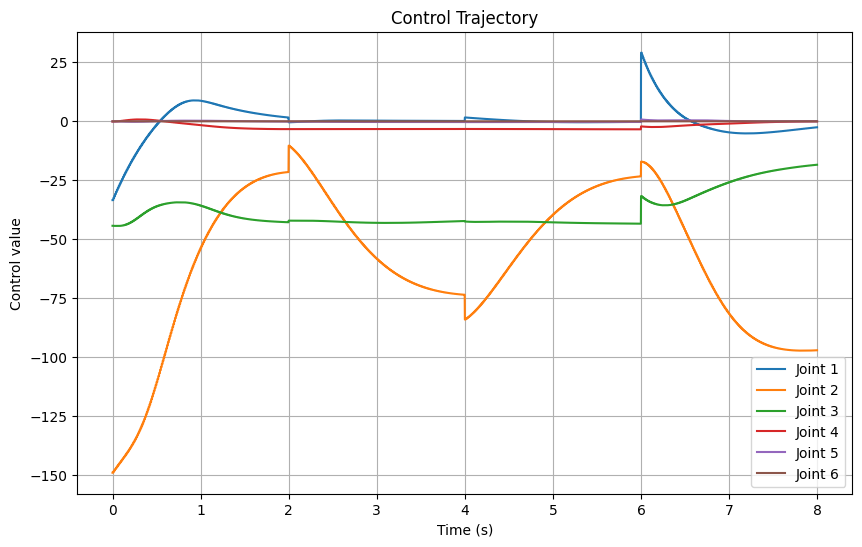

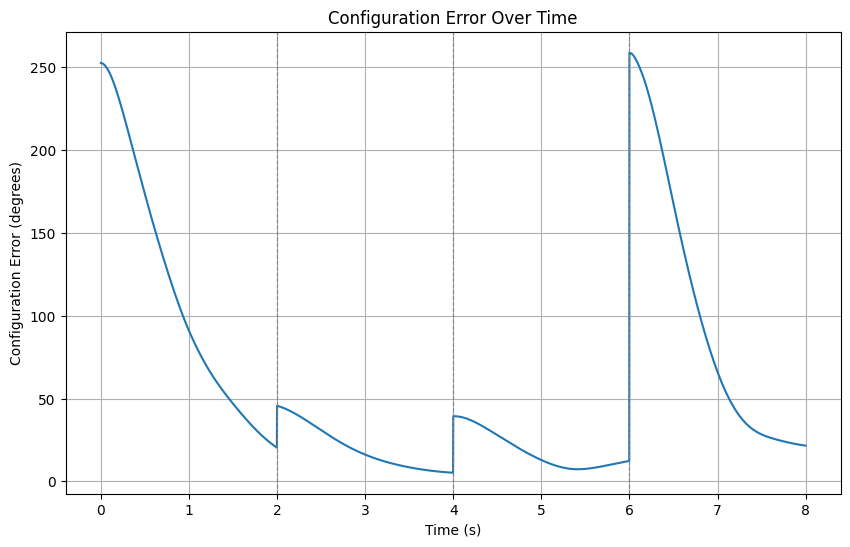

In [4]:
robot_mj_model.plot_controls(us_mpc, dt=DT)
robot_mj_model.plot_error(xs_mpc, path[1:], segment_lengths=[N_steps] * (len(path) - 1), dt=DT)


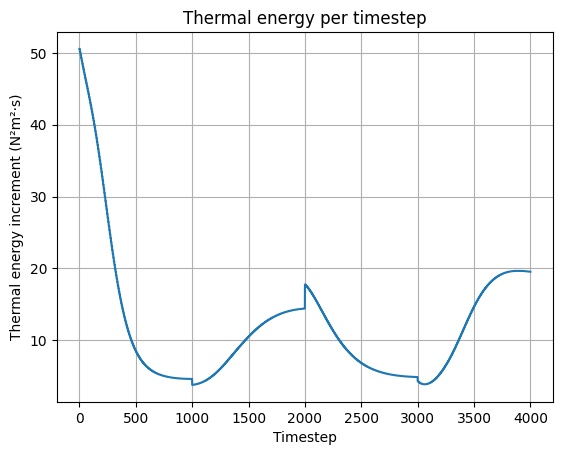

Thermal energy: 48172.74529045052


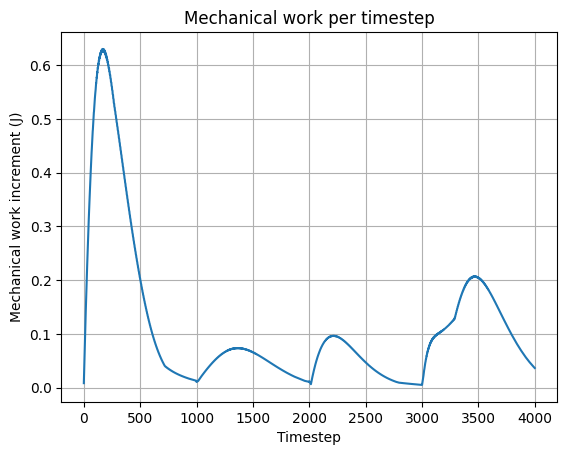

Mechanical work: 460.73953782657674


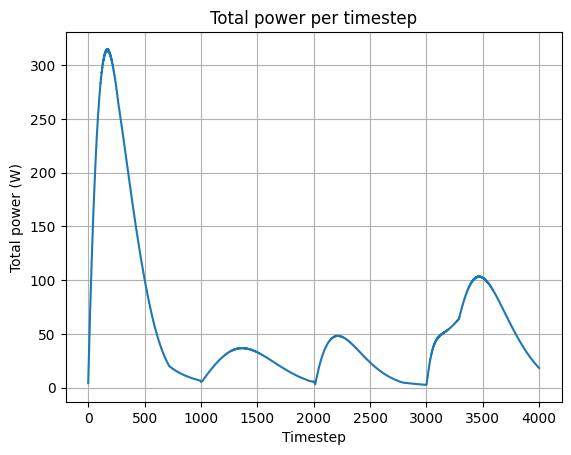

Peak power: 315.3002105284328


In [5]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_mpc, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_mpc, xs_mpc, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_mpc, xs_mpc, True)
print("Peak power:", P_peak)